# Лабораторная работа №3
### Подбор гиперпараметров ИНС

**Основа:** модель из ЛР1 — классификация новостей (NewsClassifier с EmbeddingBag).

**Алгоритмы оптимизации гиперпараметров:**
1. **GridSearch** — перебор всех комбинаций из заданной сетки
2. **Optuna** — байесовская оптимизация (Tree-structured Parzen Estimator)

**Подбираемые гиперпараметры:** learning rate, оптимизатор, функция активации, размер батча.

## 1. Установка библиотек

In [1]:
!pip install torch==2.3.0 torchtext==0.18.0 optuna --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 815.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 101.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 2. Загрузка и предобработка данных

Повторяем шаги из ЛР1 без изменений.

In [2]:
import gdown

url = "https://drive.google.com/uc?id=1Xn7ooFCZIKxfjwb83X-WOfnXEixQm1Hz"
output = "ag_news.csv"
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1Xn7ooFCZIKxfjwb83X-WOfnXEixQm1Hz
To: /content/ag_news.csv
100%|██████████| 30.2M/30.2M [00:00<00:00, 43.2MB/s]


'ag_news.csv'

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torchtext
torchtext.disable_torchtext_deprecation_warning()
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

# Загрузка
data = pd.read_csv('ag_news.csv', sep=';')

TEXT_COL  = 'content'
LABEL_COL = 'category'

data[LABEL_COL] = data[LABEL_COL].astype('category')
categories = dict(enumerate(data[LABEL_COL].cat.categories))
data[LABEL_COL] = data[LABEL_COL].cat.codes

# Разделение
X = data[TEXT_COL]
y = data[LABEL_COL]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val,  y_train, y_val  = train_test_split(X_train, y_train, test_size=0.1875, random_state=42)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# Словарь
tokenizer = get_tokenizer('basic_english')

def yield_tokens(texts):
    for text in texts:
        yield tokenizer(text)

vocab = build_vocab_from_iterator(yield_tokens(X_train), specials=["<unk>"])
vocab.set_default_index(vocab["<unk>"])
print(f"Размер словаря: {len(vocab)}")

Train: 78000, Val: 18000, Test: 24000
Размер словаря: 78225


## 3. Dataset, DataLoader и архитектура модели

In [4]:
class NewsDataset(Dataset):
    def __init__(self, data_text, labels):
        self.data = data_text.reset_index(drop=True)
        self.y    = labels.reset_index(drop=True)

    def __len__(self):  return len(self.data)

    def __getitem__(self, idx):
        text = vocab(tokenizer(self.data[idx]))
        return torch.tensor(text, dtype=torch.int64), torch.tensor(self.y[idx], dtype=torch.int64)


def collate_batch(batch):
    label_list, text_list, offsets = [], [], [0]
    for (_text, _label) in batch:
        label_list.append(_label)
        text_list.append(_text.clone().detach())
        offsets.append(_text.size(0))
    label_list = torch.tensor(label_list, dtype=torch.int64)
    offsets    = torch.tensor(offsets[:-1]).cumsum(dim=0)
    text_list  = torch.cat(text_list)
    return label_list, text_list, offsets


trainset = NewsDataset(X_train, y_train)
valset   = NewsDataset(X_val,   y_val)
testset  = NewsDataset(X_test,  y_test)

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_class = len(categories)
vocab_size = len(vocab)
EMBED_DIM  = 128

print(f"Device: {device}, Классов: {num_class}")

Device: cuda, Классов: 4


In [5]:
# Модель (параметризованная функция активации)
class NewsClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_class, activation: nn.Module):
        super().__init__()
        self.embedding = nn.EmbeddingBag(vocab_size, embed_dim, sparse=False)
        self.fc1 = nn.Linear(embed_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, num_class)
        self.act = activation
        self.drop1 = nn.Dropout(0.3)
        self.drop2 = nn.Dropout(0.3)

    def forward(self, text, offsets):
        x = self.embedding(text, offsets)
        x = self.drop1(self.act(self.bn1(self.fc1(x))))
        x = self.drop2(self.act(self.bn2(self.fc2(x))))
        return self.fc3(x)

## 4. Вспомогательная функция обучения и оценки

Одна функция train_and_eval используется обоими алгоритмами поиска. Она обучает модель за num_epochs эпох и возвращает accuracy на валидации.

In [6]:
ACTIVATIONS = {
    'ReLU':      nn.ReLU(),
    'LeakyReLU': nn.LeakyReLU(0.1),
    'ELU':       nn.ELU(alpha=1.0),
}

def build_optimizer(name, params, lr):
    if name == 'SGD':
        return optim.SGD(params, lr=lr, momentum=0.9)
    elif name == 'Adam':
        return optim.Adam(params, lr=lr)
    elif name == 'RMSprop':
        return optim.RMSprop(params, lr=lr)
    raise ValueError(f"Unknown optimizer: {name}")

# Обучает NewsClassifier с заданными гиперпараметрами.vВозвращает accuracy на валидационной выборке.
def train_and_eval(lr, optimizer_name, activation_name, batch_size, num_epochs=1):
    loader_train = DataLoader(trainset, batch_size=batch_size, shuffle=True,  collate_fn=collate_batch)
    loader_val   = DataLoader(valset,   batch_size=64,         shuffle=False, collate_fn=collate_batch)

    net = NewsClassifier(vocab_size, EMBED_DIM, num_class, ACTIVATIONS[activation_name]).to(device)
    opt = build_optimizer(optimizer_name, net.parameters(), lr)
    criterion = nn.CrossEntropyLoss().to(device)

    for _ in range(num_epochs):
        net.train()
        for labels, inputs, offsets in loader_train:
            labels, inputs, offsets = labels.to(device), inputs.to(device), offsets.to(device)
            opt.zero_grad()
            loss = criterion(net(inputs, offsets), labels)
            loss.backward()
            opt.step()

    # Валидация
    net.eval()
    correct = total = 0
    with torch.no_grad():
        for labels, inputs, offsets in loader_val:
            labels, inputs, offsets = labels.to(device), inputs.to(device), offsets.to(device)
            _, preds = torch.max(net(inputs, offsets), 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    return correct / total

## 5. GridSearch

Полный перебор всех комбинаций из сетки параметров. Гарантированно находит лучшую комбинацию в пределах сетки, но требует O(N) вычислений, где N = произведение числа значений каждого параметра.

In [7]:
from sklearn.model_selection import ParameterGrid
import time

param_grid = {
    'lr':           [0.001, 0.01],
    'optimizer':    ['SGD', 'Adam', 'RMSprop'],
    'activation':   ['ReLU', 'LeakyReLU', 'ELU'],
    'batch_size':   [16, 32],
}

# Всего комбинаций: 2 * 3 * 3 * 2 = 36
all_combinations = list(ParameterGrid(param_grid))
print(f"Всего комбинаций для перебора: {len(all_combinations)}")

gs_results = []
gs_best_acc, gs_best_params = 0.0, None

gs_start = time.time()

for i, params in enumerate(all_combinations, 1):
    acc = train_and_eval(
        lr             = params['lr'],
        optimizer_name = params['optimizer'],
        activation_name= params['activation'],
        batch_size     = params['batch_size'],
    )
    gs_results.append({'params': params, 'val_acc': acc})
    if acc > gs_best_acc:
        gs_best_acc, gs_best_params = acc, params
    print(f"[{i:02d}/{len(all_combinations)}] {params} -> val_acc={acc:.4f}")

gs_time = time.time() - gs_start

print(f"GridSearch завершён за {gs_time:.1f} сек")
print(f"Лучшие параметры: {gs_best_params}")
print(f"Лучшая val accuracy: {gs_best_acc:.4f}")

Всего комбинаций для перебора: 36
[01/36] {'activation': 'ReLU', 'batch_size': 16, 'lr': 0.001, 'optimizer': 'SGD'} -> val_acc=0.5901
[02/36] {'activation': 'ReLU', 'batch_size': 16, 'lr': 0.001, 'optimizer': 'Adam'} -> val_acc=0.8884
[03/36] {'activation': 'ReLU', 'batch_size': 16, 'lr': 0.001, 'optimizer': 'RMSprop'} -> val_acc=0.8834
[04/36] {'activation': 'ReLU', 'batch_size': 16, 'lr': 0.01, 'optimizer': 'SGD'} -> val_acc=0.6701
[05/36] {'activation': 'ReLU', 'batch_size': 16, 'lr': 0.01, 'optimizer': 'Adam'} -> val_acc=0.9056
[06/36] {'activation': 'ReLU', 'batch_size': 16, 'lr': 0.01, 'optimizer': 'RMSprop'} -> val_acc=0.9022
[07/36] {'activation': 'ReLU', 'batch_size': 32, 'lr': 0.001, 'optimizer': 'SGD'} -> val_acc=0.5723
[08/36] {'activation': 'ReLU', 'batch_size': 32, 'lr': 0.001, 'optimizer': 'Adam'} -> val_acc=0.8773
[09/36] {'activation': 'ReLU', 'batch_size': 32, 'lr': 0.001, 'optimizer': 'RMSprop'} -> val_acc=0.8757
[10/36] {'activation': 'ReLU', 'batch_size': 32, 'lr':

## 6. Optuna

Optuna использует алгоритм **TPE (Tree-structured Parzen Estimator)** — байесовский подход. Вместо полного перебора он строит вероятностную модель пространства гиперпараметров и выбирает следующую точку так, чтобы максимизировать ожидаемое улучшение. Это позволяет найти хорошее решение за меньшее число испытаний.

Здесь мы ограничиваемся 20 испытаниями (n_trials=20).

In [9]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # убираем лишний вывод

# Целевая функция для Optuna, максимизируем val accuracy
def optuna_objective(trial):
    lr             = trial.suggest_categorical('lr',           [0.001, 0.01])
    optimizer_name = trial.suggest_categorical('optimizer',    ['SGD', 'Adam', 'RMSprop'])
    activation_name= trial.suggest_categorical('activation',   ['ReLU', 'LeakyReLU', 'ELU'])
    batch_size     = trial.suggest_categorical('batch_size',   [16, 32])

    return train_and_eval(lr, optimizer_name, activation_name, batch_size)


optuna_start = time.time()

study = optuna.create_study(direction='maximize')
study.optimize(optuna_objective, n_trials=20, show_progress_bar=True)

optuna_time = time.time() - optuna_start

print(f"Optuna завершена за {optuna_time:.1f} сек ({20} испытаний)")
print(f"Лучшие параметры: {study.best_params}")
print(f"Лучшая val accuracy: {study.best_value:.4f}")

  0%|          | 0/20 [00:00<?, ?it/s]

Optuna завершена за 316.8 сек (20 испытаний)
Лучшие параметры: {'lr': 0.01, 'optimizer': 'RMSprop', 'activation': 'ELU', 'batch_size': 32}
Лучшая val accuracy: 0.9105


## 7. Сравнение алгоритмов

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Сводная таблица

print(f"{'Метрика':<30} {'GridSearch':>12} {'Optuna':>12}")
print(f"{'Лучшая val accuracy':<30} {gs_best_acc:>12.4f} {study.best_value:>12.4f}")
print(f"{'Время (сек)':<30} {gs_time:>12.1f} {optuna_time:>12.1f}")
print(f"{'Число испытаний':<30} {len(all_combinations):>12} {20:>12}")
print(f"{'Испытаний на сек':<30} {len(all_combinations)/gs_time:>12.2f} {20/optuna_time:>12.2f}")
print(f"\nGridSearch лучшие параметры:")
for k, v in gs_best_params.items():
    print(f"  {k}: {v}")
print(f"\nOptuna лучшие параметры:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Метрика                          GridSearch       Optuna
Лучшая val accuracy                  0.9102       0.9105
Время (сек)                           649.7        316.8
Число испытаний                          36           20
Испытаний на сек                       0.06         0.06

GridSearch лучшие параметры:
  activation: ELU
  batch_size: 32
  lr: 0.01
  optimizer: Adam

Optuna лучшие параметры:
  lr: 0.01
  optimizer: RMSprop
  activation: ELU
  batch_size: 32


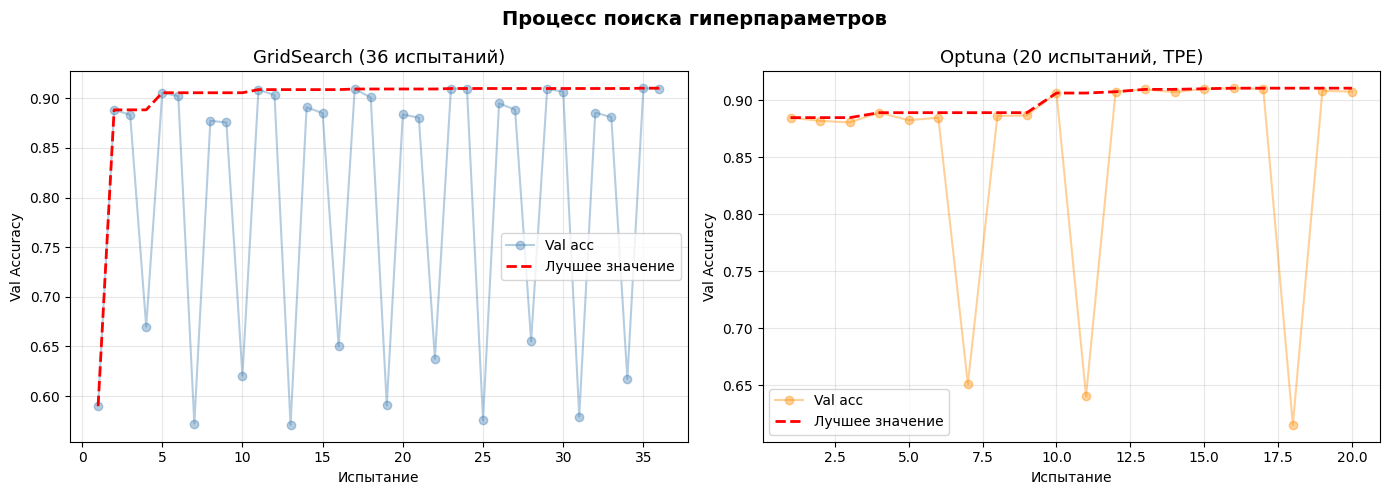

In [12]:
# График: точность по испытаниям
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GridSearch: все результаты
gs_accs = [r['val_acc'] for r in gs_results]
gs_best_so_far = [max(gs_accs[:i+1]) for i in range(len(gs_accs))]

axes[0].plot(range(1, len(gs_accs)+1), gs_accs, 'o-', alpha=0.4, color='steelblue', label='Val acc')
axes[0].plot(range(1, len(gs_accs)+1), gs_best_so_far, 'r--', linewidth=2, label='Лучшее значение')
axes[0].set_title(f'GridSearch ({len(all_combinations)} испытаний)', fontsize=13)
axes[0].set_xlabel('Испытание')
axes[0].set_ylabel('Val Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Optuna: кривая оптимизации
optuna_values = [t.value for t in study.trials]
optuna_best_so_far = [max(optuna_values[:i+1]) for i in range(len(optuna_values))]

axes[1].plot(range(1, len(optuna_values)+1), optuna_values, 'o-', alpha=0.4, color='darkorange', label='Val acc')
axes[1].plot(range(1, len(optuna_values)+1), optuna_best_so_far, 'r--', linewidth=2, label='Лучшее значение')
axes[1].set_title(f'Optuna (20 испытаний, TPE)', fontsize=13)
axes[1].set_xlabel('Испытание')
axes[1].set_ylabel('Val Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Процесс поиска гиперпараметров', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1402/4098359168.py:4: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


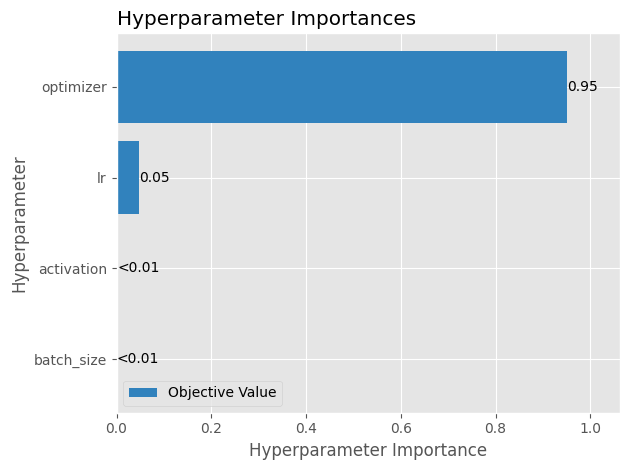

In [18]:
# Визуализация важности параметров (Optuna)
try:
    from optuna.visualization.matplotlib import plot_param_importances
    plot_param_importances(study)
    # plt.title('Важность гиперпараметров (Optuna)')
    plt.tight_layout()
    plt.show()
except Exception:
    # Ручной расчёт через корреляцию
    import pandas as pd
    trials_df = study.trials_dataframe()
    print("Параметры всех испытаний Optuna:")
    print(trials_df[['params_lr','params_optimizer','params_activation','params_batch_size','value']].to_string())

## 8. Обучение финальной модели с лучшими параметрами

Берём лучшие параметры от GridSearch (как наиболее полного перебора) и обучаем финальную модель на полных 20 эпохах.

In [15]:
best_params = study.best_params
print("Финальные параметры:", best_params)

# Финальное обучение на 20 эпохах
FINAL_EPOCHS = 20

final_loader_train = DataLoader(trainset, batch_size=best_params['batch_size'], shuffle=True,  collate_fn=collate_batch)
final_loader_val   = DataLoader(valset,   batch_size=64,                        shuffle=False, collate_fn=collate_batch)
final_loader_test  = DataLoader(testset,  batch_size=64,                        shuffle=False, collate_fn=collate_batch)

final_net = NewsClassifier(vocab_size, EMBED_DIM, num_class,
                            ACTIVATIONS[best_params['activation']]).to(device)
final_opt = build_optimizer(best_params['optimizer'], final_net.parameters(), best_params['lr'])
criterion = nn.CrossEntropyLoss().to(device)

best_val_acc = 0.0
patience, patience_counter = 5, 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(FINAL_EPOCHS):
    # Обучение
    final_net.train()
    running_loss = running_correct = total_batches = 0
    for labels, inputs, offsets in final_loader_train:
        labels, inputs, offsets = labels.to(device), inputs.to(device), offsets.to(device)
        final_opt.zero_grad()
        outputs = final_net(inputs, offsets)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        loss.backward()
        final_opt.step()
        running_loss    += loss.item()
        running_correct += (preds == labels).float().mean().item()
        total_batches   += 1

    train_loss = running_loss / total_batches
    train_acc  = running_correct / total_batches

    # Валидация
    final_net.eval()
    val_loss = val_correct = val_batches = 0
    with torch.no_grad():
        for labels, inputs, offsets in final_loader_val:
            labels, inputs, offsets = labels.to(device), inputs.to(device), offsets.to(device)
            outputs = final_net(inputs, offsets)
            _, preds = torch.max(outputs, 1)
            val_loss    += criterion(outputs, labels).item()
            val_correct += (preds == labels).float().mean().item()
            val_batches += 1

    val_loss /= val_batches
    val_acc   = val_correct / val_batches

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch [{epoch+1:02d}/{FINAL_EPOCHS}] "
          f"Train Loss={train_loss:.4f} Acc={train_acc:.4f} | "
          f"Val Loss={val_loss:.4f} Acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(final_net.state_dict(), 'best_final_model.pt')
        patience_counter = 0
        print("  Сохранена лучшая модель")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("  Early stopping")
            break

print(f"\nЛучшая val accuracy финальной модели: {best_val_acc:.4f}")

Финальные параметры: {'lr': 0.01, 'optimizer': 'RMSprop', 'activation': 'ELU', 'batch_size': 32}
Epoch [01/20] Train Loss=0.3829 Acc=0.8715 | Val Loss=0.2696 Acc=0.9111
  Сохранена лучшая модель
Epoch [02/20] Train Loss=0.2428 Acc=0.9205 | Val Loss=0.2661 Acc=0.9113
  Сохранена лучшая модель
Epoch [03/20] Train Loss=0.1959 Acc=0.9347 | Val Loss=0.2623 Acc=0.9115
  Сохранена лучшая модель
Epoch [04/20] Train Loss=0.1638 Acc=0.9450 | Val Loss=0.2845 Acc=0.9104
Epoch [05/20] Train Loss=0.1402 Acc=0.9530 | Val Loss=0.2899 Acc=0.9104
Epoch [06/20] Train Loss=0.1215 Acc=0.9587 | Val Loss=0.3291 Acc=0.9031
Epoch [07/20] Train Loss=0.1033 Acc=0.9664 | Val Loss=0.3393 Acc=0.9018
Epoch [08/20] Train Loss=0.0899 Acc=0.9704 | Val Loss=0.3521 Acc=0.9038
  Early stopping

Лучшая val accuracy финальной модели: 0.9115


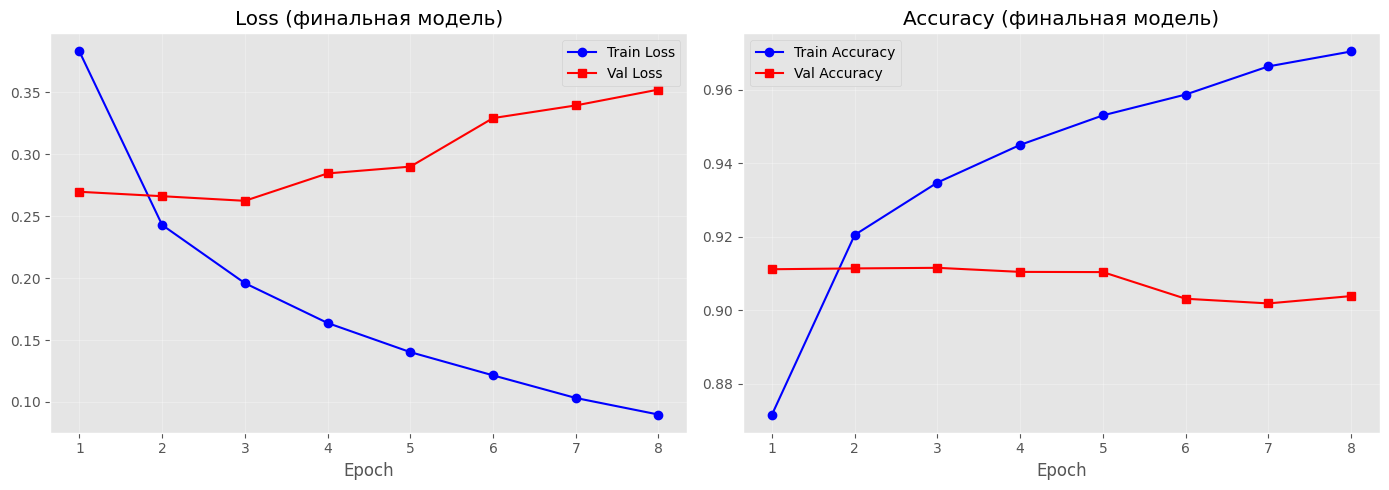

In [16]:
# Кривые обучения финальной модели
epochs_range = range(1, len(history['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, history['train_loss'], 'o-', color='blue',  label='Train Loss')
ax1.plot(epochs_range, history['val_loss'],   's-', color='red',   label='Val Loss')
ax1.set_title('Loss (финальная модель)'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history['train_acc'],  'o-', color='blue',  label='Train Accuracy')
ax2.plot(epochs_range, history['val_acc'],    's-', color='red',   label='Val Accuracy')
ax2.set_title('Accuracy (финальная модель)'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Финальное тестирование

In [17]:
from sklearn.metrics import classification_report

# Загружаем лучшую сохранённую модель
final_net.load_state_dict(torch.load('best_final_model.pt', map_location=device))
final_net.eval()

all_preds, all_labels = [], []
correct = total = 0

with torch.no_grad():
    for labels, inputs, offsets in final_loader_test:
        labels, inputs, offsets = labels.to(device), inputs.to(device), offsets.to(device)
        outputs = final_net(inputs, offsets)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total   += labels.size(0)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = correct / total
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print()
print(classification_report(all_labels, all_preds,
                             target_names=list(categories.values())))

Test Accuracy: 0.9182 (91.82%)

              precision    recall  f1-score   support

          IT       0.90      0.90      0.90      6038
    business       0.90      0.88      0.89      6064
       crime       0.92      0.92      0.92      5962
       sport       0.95      0.98      0.97      5936

    accuracy                           0.92     24000
   macro avg       0.92      0.92      0.92     24000
weighted avg       0.92      0.92      0.92     24000



## 10. Выводы

### Когда что использовать

- **GridSearch** — подходит, когда параметров мало (2–3) и каждый принимает небольшое число значений. Даёт воспроизводимый и исчерпывающий результат.
- **Optuna** — предпочтителен для большого числа параметров или когда обучение дорогое. TPE быстрее находит хорошую область пространства, умеет работать с непрерывными диапазонами и поддерживает early pruning (прерывание заведомо плохих испытаний).